In [1]:
import fitsio as F
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import glob
plt.style.use(['science', 'notebook', 'grid'])
ABACUS_PATH= '/user/shadab/globus_data/cosmosim/NFW_Abacus/'

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Abacus information

In AbacusSummit_base_c*\_ph*, 
### c*** stands for comsology: 

c000 is a Planck2018 ΛCDM version


c001–c004 — four secondary cosmologies with meaningfully different physics. 


c001 is a WMAP7 model with low Ω_c; 


c002 is a thawing wCDM model with w₀=−0.7, wₐ=−0.5;


c003 is an N_eff=3.70 model; 


c004 is low σ₈,matter=0.75, otherwise baseline ΛCDM.

### ph*** — phase identifier
The initial-conditions random seed — same cosmology, different realization of the random Gaussian initial density field. Different realizations of the same cosmology are labelled by a three-digit or four-digit phase number, included as ph000 in the simulation name.


In [2]:
test_file = ABACUS_PATH+'/AbacusSummit_base_c000_ph000/z0.100/sub_0_nsub_4.fits'
all_files = glob.glob(ABACUS_PATH+'/AbacusSummit_base_c000_ph000/z0.100/sub_*.fits')

In [ ]:
data, hdr = F.read(test_file, header=True)
print(data.dtype.names)
print(len(data))   # columns
print(hdr)

('x_L2com', 'v_L2com', 'Mvir', 'rvir', 'rs', 'vrms', 'Mabacus', 'fit_quality', 'abacus_index', 'Mabacus_clean')
5950274

XTENSION= 'BINTABLE'           / binary table extension
BITPIX  =                    8 / 8-bit bytes
NAXIS   =                    2 / 2-dimensional binary table
NAXIS1  =                   60 / width of table in bytes
NAXIS2  =              5950274 / number of rows in table
PCOUNT  =                    0 / size of special data area
GCOUNT  =                    1 / one data group (required keyword)
TFIELDS =                   10 / number of fields in each row
TTYPE1  = 'x_L2com'            / label for field   1
TFORM1  = '3E'                 / data format of field: 4-byte REAL
TTYPE2  = 'v_L2com'            / label for field   2
TFORM2  = '3E'                 / data format of field: 4-byte REAL
TTYPE3  = 'Mvir'               / label for field   3
TFORM3  = 'E'                  / data format of field: 4-byte REAL
TTYPE4  = 'rvir'               / label for field   4
TFO

In [9]:
tot_obj = 0
for file in all_files: 
    data, hdr = F.read(file, header=True)
    #print(data.dtype.names)
    print(len(data))   # columns
    #print(hdr)
    tot_obj += len(data)
print('Total number of objects in all files:', tot_obj)

6046184
6065182
6031669
5920489
5950699
5986151
6030120
5925128
5987524
6108409
5963424
5921754
5952386
5949882
5987095
5975364
5987095
6052889
5974750
6003232
5859123
5940912
5980967
5870177
5973687
5946384
5933277
5947351
5911231
6077773
6021387
5983148
5950274
6002448
5993861
6048869
6037443
6093910
6086488
6058113
5963384
5983843
5868562
5915430
5909832
6035712
5968879
6004825
6029319
6001704
5918171
5917036
5998811
5984825
5937550
5905314
5870759
6005138
5916123
5944992
5993998
6002814
5905455
5955942
Total number of objects in all files: 382474667


In [8]:
print('Total number of objects in all files:', f'{tot_obj:,}')

Total number of objects in all files: 382,474,667


In [10]:
h = data[0]
print("position [Mpc/h]:", h['x_L2com'])
print("velocity [km/s]  :", h['v_L2com'])
print("Mvir [Msun/h]    :", h['Mvir'])
print("rvir [Mpc/h]     :", h['rvir'])
print("rs   [Mpc/h]     :", h['rs'])
print("concentration    :", h['rvir']/h['rs'])
print("vrms [km/s]      :", h['vrms'])

position [Mpc/h]: [1000.0843    500.94153    61.631287]
velocity [km/s]  : [-133.00658  371.65454 -557.95264]
Mvir [Msun/h]    : 422143620000.0
rvir [Mpc/h]     : 0.25524962
rs   [Mpc/h]     : 0.012742306
concentration    : 20.031666
vrms [km/s]      : 329.60696


70865140000.0 1671705000000000.0
[1.00000006e+03 5.00000031e+02 1.83105469e-04] [1500.     1000.      499.9997]
0.017495304


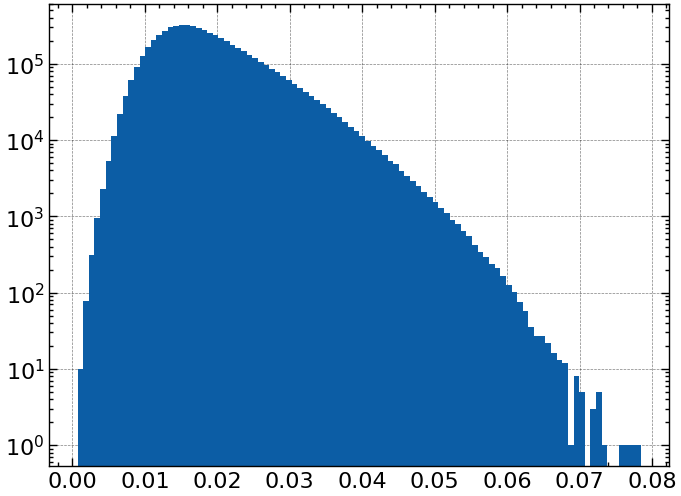

In [12]:
print(data['Mvir'].min(), data['Mvir'].max())
print(data['x_L2com'].min(axis=0), data['x_L2com'].max(axis=0))  # should span subbox range, not full box
print(np.median(data['fit_quality']))
plt.hist(data['fit_quality'], bins=100)
plt.yscale('log')

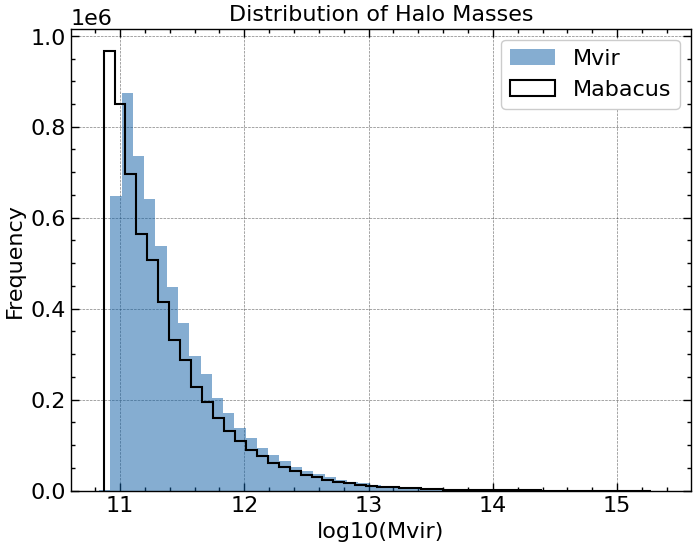

In [55]:
plt.hist(np.log10(data['Mvir']), bins=50,alpha = 0.5, label='Mvir')
plt.hist(np.log10(data['Mabacus']), bins=50,alpha = 1,lw =1.5, histtype='step', label='Mabacus',color='k')

plt.xlabel('log10(Mvir)')
plt.ylabel('Frequency')
plt.title('Distribution of Halo Masses')
plt.legend()
plt.show()

In [13]:
particle_mass = 2.109081520453063e9  # Msun/h
boxsize = 2000.0  # Mpc/h
min_mass = 35 * particle_mass  # ~7.4e10 Msun/h, resolution floor

# apply floor
good = data['Mvir'] > min_mass
print(good.sum(), '/', len(data))

5955939 / 5955942


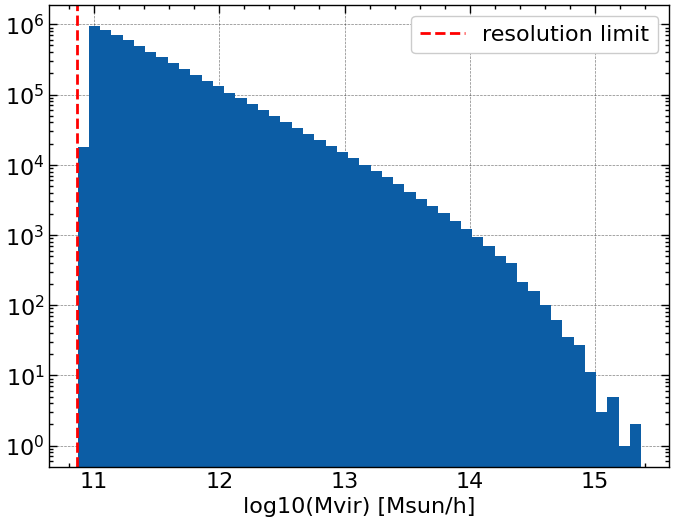

In [31]:


logM = np.log10(data['Mvir'][good])
plt.hist(logM, bins=50, log=True)
plt.axvline(np.log10(min_mass), color='r', ls='--', label='resolution limit')
plt.xlabel('log10(Mvir) [Msun/h]')
plt.legend()

In [22]:

# constants from your header
BOXSIZE = 2000.0          # Mpc/h
PMASS   = 2109081520.453063  # Msun/h, particle mass
MIN_NP  = 35              # min particles per halo
MMIN    = MIN_NP * PMASS  # ~7.4e10 Msun/h resolution floor
Z       = 0.1



In [23]:
MMIN

73817853215.85721

In [26]:
data[~good]['Mvir']

array([7.086514e+10, 7.293204e+10, 7.381785e+10], dtype='>f4')

In [25]:
good = data['Mvir'] > MMIN
print(f"{good.sum():,} / {len(data):,} halos survive the {MMIN:.2e} Msun/h cut")
d = data[good]   # work with this from now on

5,955,939 / 5,955,942 halos survive the 7.38e+10 Msun/h cut


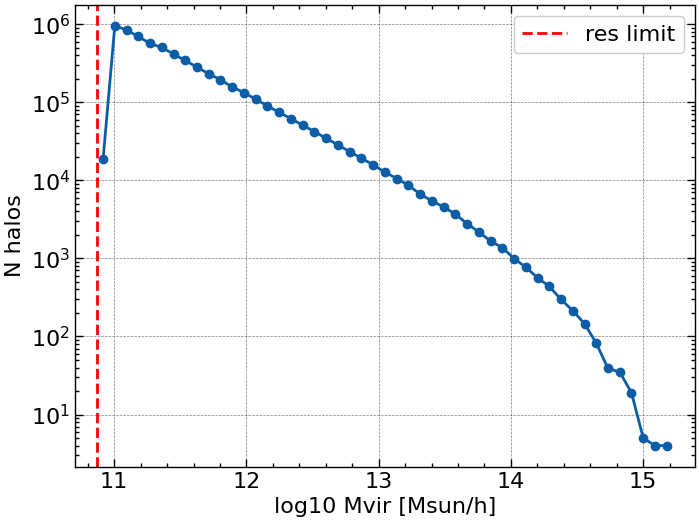

In [27]:
logM = np.log10(d['Mvir'])
bins = np.linspace(logM.min(), logM.max(), 50)
counts, edges = np.histogram(logM, bins=bins)
centers = 0.5*(edges[1:]+edges[:-1])

# convert to dn/dlogM per (Mpc/h)^3
subvol = ... # your subbox volume; if 1/4 of box = 2000^3/4
dlogM = edges[1]-edges[0]
# (fill subvol correctly based on your step 2 finding)

plt.figure()
plt.plot(centers, counts, 'o-')
plt.axvline(np.log10(MMIN), color='r', ls='--', label='res limit')
plt.yscale('log')
plt.xlabel('log10 Mvir [Msun/h]'); plt.ylabel('N halos')
plt.legend()

In [64]:
slab['x_L2com']

array([[9.86083984e-01, 1.55914307e+00, 1.00682556e+02],
       [1.08105469e+00, 2.08544922e+00, 1.00884338e+02],
       [1.17626953e+00, 3.03521729e+00, 1.02971497e+02],
       ...,
       [3.95202637e-01, 4.42964355e+02, 1.00964905e+02],
       [9.64355469e-03, 4.86361328e+02, 1.08385010e+02],
       [4.76074219e-03, 4.98479858e+02, 1.05878357e+02]], dtype='>f4')

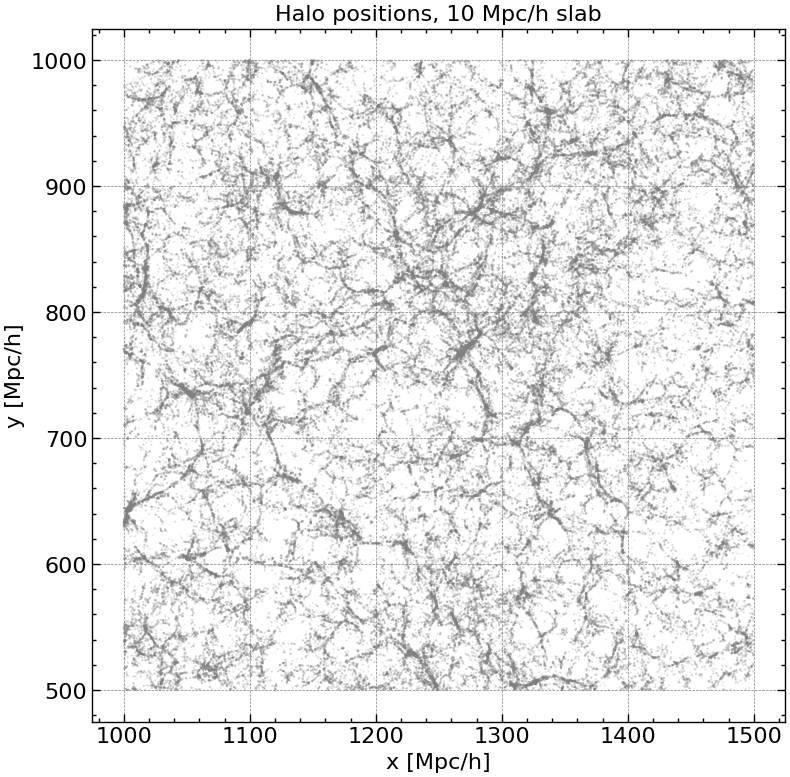

In [28]:
# thin slab in z, plot x-y
slab = d[(d['x_L2com'][:,2] > 100) & (d['x_L2com'][:,2] < 110)]  # 10 Mpc/h thick

plt.figure(figsize=(9,9))
plt.scatter(slab['x_L2com'][:,0], slab['x_L2com'][:,1],
            s=0.5*np.log10(slab['Mvir']/MMIN), alpha=0.3, c='gray')
plt.xlabel('x [Mpc/h]'); plt.ylabel('y [Mpc/h]')
plt.title('Halo positions, 10 Mpc/h slab')
plt.gca().set_aspect('equal')

Text(0, 0.5, 'median concentration')

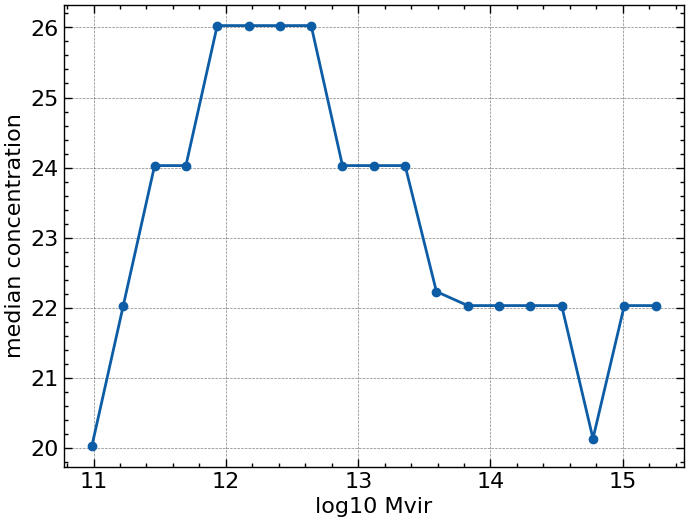

In [40]:
c = d['rvir'] / d['rs']
valid = (c > 1) & (c < 50) & np.isfinite(c)   # sane NFW range

# median c in mass bins
mbins = np.linspace(logM.min(), logM.max(), 20)
idx = np.digitize(np.log10(d['Mvir'][valid]), mbins)
mc = [np.median(c[valid][idx==i]) for i in range(1,len(mbins))]
mcent = 0.5*(mbins[1:]+mbins[:-1])

plt.figure()
plt.plot(mcent, mc, 'o-')
plt.xlabel('log10 Mvir'); plt.ylabel('median concentration')

Text(0, 0.5, 'log10 vrms [km/s]')

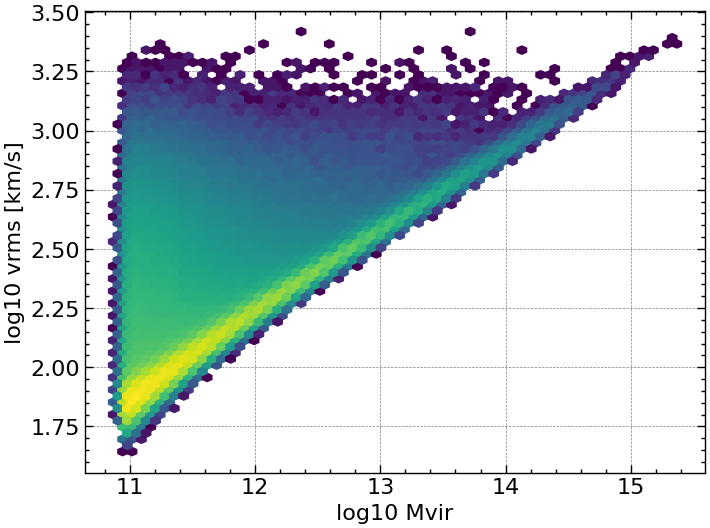

In [41]:
plt.figure()
plt.hexbin(np.log10(d['Mvir']), np.log10(d['vrms']), gridsize=60, bins='log')
plt.xlabel('log10 Mvir'); plt.ylabel('log10 vrms [km/s]')

Text(0, 0.5, 'log10 Mvir')

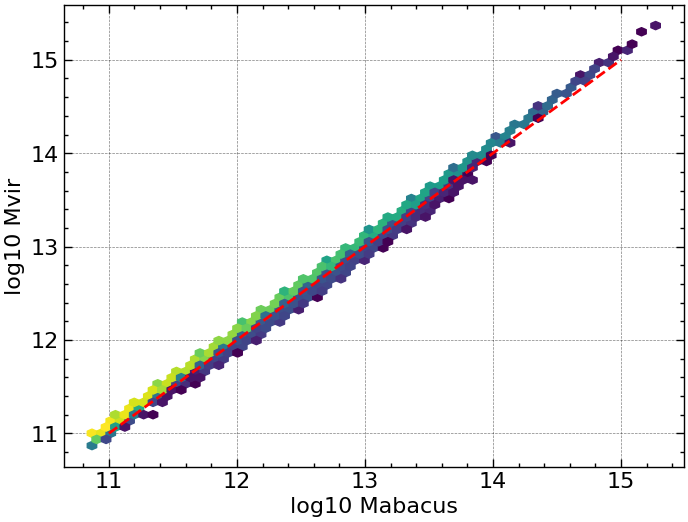

In [42]:
plt.figure()
plt.hexbin(np.log10(d['Mabacus']), np.log10(d['Mvir']), gridsize=60, bins='log')
plt.plot([11,15],[11,15],'r--')
plt.xlabel('log10 Mabacus'); plt.ylabel('log10 Mvir')

In [70]:
ABACUS_PATH_BASE ='/user/shadab/globus_data/cosmosim/NFW_Abacus/AbacusSummit_base_c000_ph000/z0.100/'
files = sorted(glob.glob(ABACUS_PATH_BASE + 'sub_*_nsub_4.fits'))
print(len(files), 'files')   # expect 64

# check the spatial extent of a few subboxes
for f in files[:5] + files[-2:]:
    p = F.read(f, columns=['x_L2com'])['x_L2com']
    lo = p.min(axis=0); hi = p.max(axis=0)
    print(f.split('/')[-1],
          f"x[{lo[0]:.0f},{hi[0]:.0f}] y[{lo[1]:.0f},{hi[1]:.0f}] z[{lo[2]:.0f},{hi[2]:.0f}]")

64 files
sub_0_nsub_4.fits x[0,500] y[0,500] z[0,500]
sub_10_nsub_4.fits x[0,500] y[1000,1500] z[1000,1500]
sub_11_nsub_4.fits x[0,500] y[1000,1500] z[1500,2000]
sub_12_nsub_4.fits x[0,500] y[1500,2000] z[0,500]
sub_13_nsub_4.fits x[0,500] y[1500,2000] z[500,1000]
sub_8_nsub_4.fits x[0,500] y[1000,1500] z[0,500]
sub_9_nsub_4.fits x[0,500] y[1000,1500] z[500,1000]


In [72]:
def subbox_center(f):
    p = F.read(f, columns=['x_L2com'])['x_L2com']
    return p.mean(axis=0)

for i, f in enumerate(files):
    c = subbox_center(f)
    cell = (c // 500).astype(int)   # which of the 4x4x4 cells
    print(i, cell)

0 [0 0 0]
1 [0 2 2]
2 [0 2 3]
3 [0 3 0]
4 [0 3 1]
5 [0 3 2]
6 [0 3 3]
7 [1 0 0]
8 [1 0 1]
9 [1 0 2]
10 [1 0 3]
11 [0 0 1]
12 [1 1 0]
13 [1 1 1]
14 [1 1 2]
15 [1 1 3]
16 [1 2 0]
17 [1 2 1]
18 [1 2 2]
19 [1 2 3]
20 [1 3 0]
21 [1 3 1]
22 [0 0 2]
23 [1 3 2]
24 [1 3 3]
25 [2 0 0]
26 [2 0 1]
27 [2 0 2]
28 [2 0 3]
29 [2 1 0]
30 [2 1 1]
31 [2 1 2]
32 [2 1 3]
33 [0 0 3]
34 [2 2 0]
35 [2 2 1]
36 [2 2 2]
37 [2 2 3]
38 [2 3 0]
39 [2 3 1]
40 [2 3 2]
41 [2 3 3]
42 [3 0 0]
43 [3 0 1]
44 [0 1 0]
45 [3 0 2]
46 [3 0 3]
47 [3 1 0]
48 [3 1 1]
49 [3 1 2]
50 [3 1 3]
51 [3 2 0]
52 [3 2 1]
53 [3 2 2]
54 [3 2 3]
55 [0 1 1]
56 [3 3 0]
57 [3 3 1]
58 [3 3 2]
59 [3 3 3]
60 [0 1 2]
61 [0 1 3]
62 [0 2 0]
63 [0 2 1]


In [ ]:
shell = d[(d['x_L2com'][:,0] > 100) & (d['x_L2com'][:,0] < 200)]
plt.scatter(shell['x_L2com'][:,0], shell['x_L2com'][:,1],
            s=0.5*np.log10(shell['Mvir']/MMIN), alpha=0.3, c='gray')    
plt.xlabel('x [Mpc/h]'); plt.ylabel('y [Mpc/h]')
plt.title('Halo positions, 100 < x < 200 Mpc/h')

Text(0, 0.5, 'y [Mpc/h]')

In [74]:
BOXSIZE = 2000.0
PMASS   = 2.109081520453063e9
MMIN    = 35 * PMASS

d = np.concatenate([F.read(f) for f in files])
print(f"{len(d):,} halos before dedupe")   # ~64 × 5.95M if all similar size — that's huge

# drop boundary duplicates
_, uniq = np.unique(d['abacus_index'], return_index=True)
d = d[uniq]
print(f"{len(d):,} after dedupe")

d = d[d['Mvir'] > MMIN]
print(f"{len(d):,} above resolution floor")

382,474,667 halos before dedupe
382,474,667 after dedupe
382,474,270 above resolution floor


In [75]:
sizes = [F.read_header(f, ext=1)['NAXIS2'] for f in files]
print('total rows:', sum(sizes))
print('min/max per subbox:', min(sizes), max(sizes))

total rows: 382474667
min/max per subbox: 5859123 6108409
